Tamanho do dataset original: (32561, 15)
Tamanho do dataset balanceado: (49440, 16)


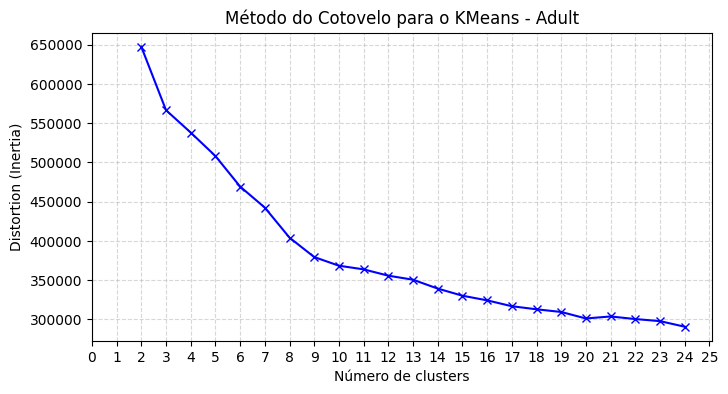

In [2]:
# Método do Cotovelo para o Dataset Adult (KMeans)

# Este notebook permite analisar o número ideal de clusters para o dataset Adult utilizando o método do cotovelo com KMeans.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
import seaborn as sns

# Carregamento e pré-processamento do dataset Adult (com balanceamento)
adult_df = pd.read_csv('../data/AdultDataset/adult.data', header=None, na_values=' ?', skipinitialspace=True)
adult_df.columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]

# Tamanho do dataset antes do balanceamento
print(f"Tamanho do dataset original: {adult_df.shape}")

adult_df = adult_df.dropna().copy()
# Cria coluna binária para income
def income_to_bin(val):
    return 1 if val.strip() == '>50K' else 0
adult_df['income_bin'] = adult_df['income'].apply(income_to_bin)
# Balanceamento por oversampling
df_majority = adult_df[adult_df['income_bin'] == 0]
df_minority = adult_df[adult_df['income_bin'] == 1]
n_majority = len(df_majority)
df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=n_majority,
    random_state=42
)
adult_df_balanced = pd.concat([df_majority, df_minority_upsampled])
adult_df_balanced = adult_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Tamanho do dataset após o balanceamento
print(f"Tamanho do dataset balanceado: {adult_df_balanced.shape}")

for col in adult_df_balanced.select_dtypes(include='object').columns:
    if col != 'income':
        adult_df_balanced[col] = LabelEncoder().fit_transform(adult_df_balanced[col].astype(str))
X = adult_df_balanced.drop(['income', 'income_bin'], axis=1).values
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Método do cotovelo
K = range(2, 25)
distortions = []
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    distortions.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K, distortions, 'bx-')
plt.xlabel('Número de clusters')
plt.ylabel('Distortion (Inertia)')
plt.title('Método do Cotovelo para o KMeans - Adult')
plt.xticks(np.arange(0, 26, 1))
plt.grid(True, which='both', axis='both', linestyle='--', alpha=0.5)
plt.savefig('../img/kmeans_adult_elbow.png')
plt.show()